<a href="https://colab.research.google.com/github/kavinraajs04/NLP_Projects/blob/main/Project_5_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud

import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [3]:
comments = [
    "Amazing product! Really loved it.",
    "Worst customer service ever.",
    "The delivery was fast and packaging was great.",
    "I hate this update.",
    "Excellent quality. Highly recommend.",
    "Very disappointed with the product.",
    "Fantastic experience!",
    "Not worth the money.",
    "Super happy with my purchase.",
    "Bad quality and slow delivery.",
    "Awesome customer support.",
    "The app is very easy to use.",
    "Terrible experience.",
    "Loved the new features.",
    "Good value for money.",
    "Poor packaging.",
    "Excellent design.",
    "Highly satisfied.",
    "Worst app ever.",
    "Very useful product."
]

df = pd.DataFrame({'Comment': comments})

df.head()

,Comment
0,Amazing product! Really loved it.
1,Worst customer service ever.
2,The delivery was fast and packaging was great.
3,I hate this update.
4,Excellent quality. Highly recommend.


In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Clean_Comment'] = df['Comment'].apply(clean_text)

df.head()

,Comment,Clean_Comment
0,Amazing product! Really loved it.,amazing product really loved
1,Worst customer service ever.,worst customer service ever
2,The delivery was fast and packaging was great.,delivery fast packaging great
3,I hate this update.,hate update
4,Excellent quality. Highly recommend.,excellent quality highly recommend


In [7]:
sia = SentimentIntensityAnalyzer()

def sentiment(comment):

    score = sia.polarity_scores(comment)['compound']

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Comment'].apply(sentiment)

df.head()

,Comment,Clean_Comment,Sentiment
0,Amazing product! Really loved it.,amazing product really loved,Positive
1,Worst customer service ever.,worst customer service ever,Negative
2,The delivery was fast and packaging was great.,delivery fast packaging great,Positive
3,I hate this update.,hate update,Negative
4,Excellent quality. Highly recommend.,excellent quality highly recommend,Positive


In [8]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,12
Negative,8


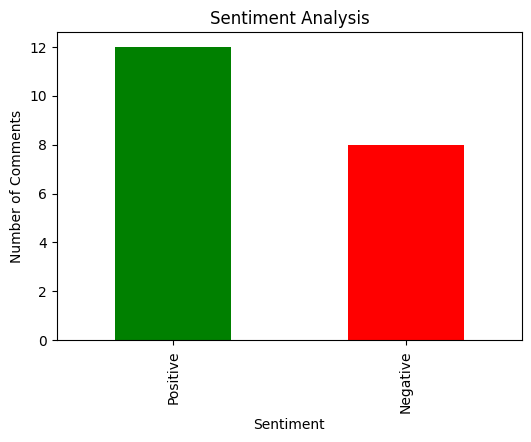

In [9]:
plt.figure(figsize=(6,4))

df['Sentiment'].value_counts().plot(kind='bar',
                                    color=['green','red','blue'])

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

In [10]:
all_words = " ".join(df['Clean_Comment'])

word_list = all_words.split()

word_freq = pd.Series(word_list).value_counts()

print(word_freq.head(20))

product       3
loved         2
delivery      2
worst         2
customer      2
ever          2
excellent     2
quality       2
highly        2
packaging     2
money         2
experience    2
app           2
amazing       1
fast          1
service       1
really        1
update        1
recommend     1
great         1
Name: count, dtype: int64


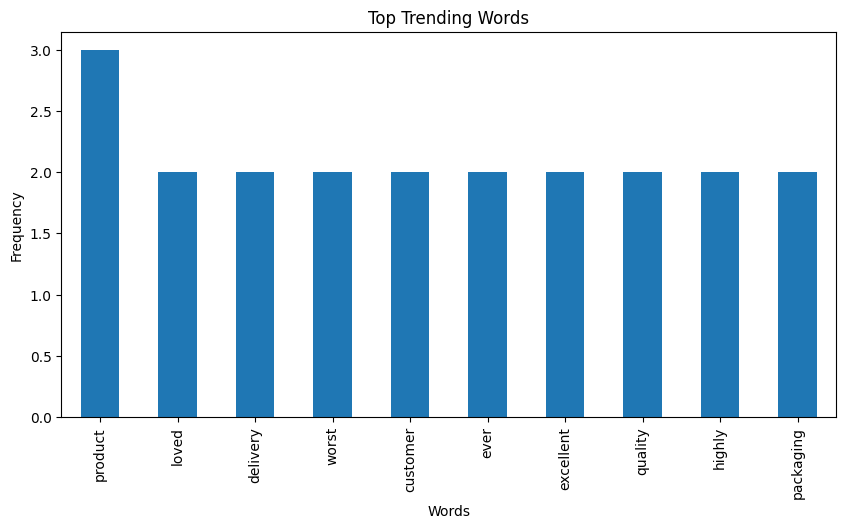

In [11]:
plt.figure(figsize=(10,5))

word_freq.head(10).plot(kind='bar')

plt.title("Top Trending Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

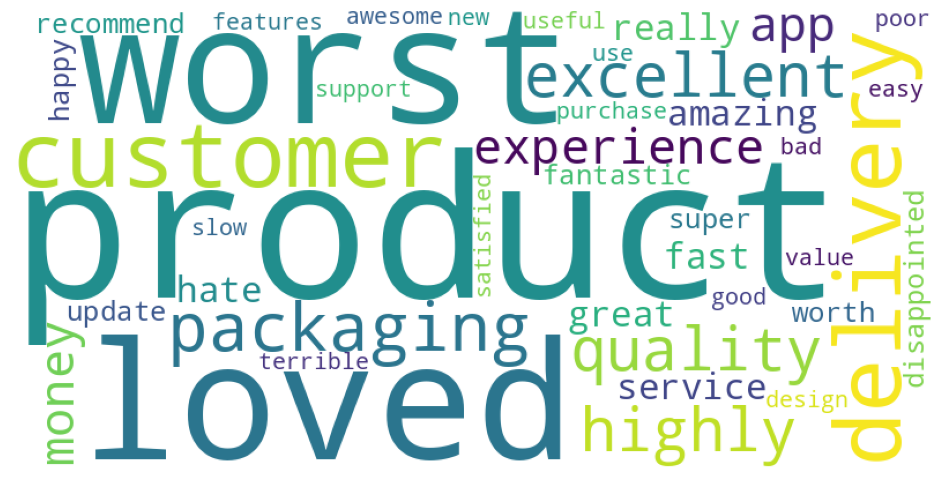

In [12]:
wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [13]:
df

,Comment,Clean_Comment,Sentiment
0,Amazing product! Really loved it.,amazing product really loved,Positive
1,Worst customer service ever.,worst customer service ever,Negative
2,The delivery was fast and packaging was great.,delivery fast packaging great,Positive
3,I hate this update.,hate update,Negative
4,Excellent quality. Highly recommend.,excellent quality highly recommend,Positive
5,Very disappointed with the product.,disappointed product,Negative
6,Fantastic experience!,fantastic experience,Positive
7,Not worth the money.,worth money,Negative
8,Super happy with my purchase.,super happy purchase,Positive
9,Bad quality and slow delivery.,bad quality slow delivery,Negative


In [14]:
df.to_csv("Social_Media_Sentiment.csv", index=False)

print("File Saved Successfully!")

File Saved Successfully!
